<a href="https://www.kaggle.com/code/gloriagrce/spam-ham-detection?scriptVersionId=237099583" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Spam Email Detection

## Goal

Our goal of this project is to develop a model with machine learning application that is capable of detecting spam emails with high accuracy.

We collectively find it interesting because there are several occasions that we experience our ham mails to be identified as spam (false positive) and would result in us not knowing that email exist therefore we decided that doing this project would be interesting and fun.

### Setup

In [1]:
# Check versions of Keras and Tensorflow
#!pip install -U keras # Don't upgrade Keras for 24SP because hw1 was still Keras 2
!pip list | egrep 'keras|tensorflow\s|jax\s'
!pip install keras-cv

jax                                0.4.33
keras                              3.5.0
keras-core                         0.1.7
keras-cv                           0.9.0
keras-hub                          0.18.1
keras-nlp                          0.18.1
keras-tuner                        1.4.7
tensorflow                         2.18.0
tf_keras                           2.18.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.4 which is incompatible.
google-api-core 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, log_loss, accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from IPython.display import display, HTML
import io
from pathlib import Path
import keras
import keras_cv
import tensorflow as tf
import tensorflow_datasets as tfds
print(f"Keras version: {keras.__version__}, backend: {keras.backend.backend()}")
num_gpus = len(tf.config.list_physical_devices('GPU'))
print(f"GPUs: {num_gpus}")
if num_gpus == 0:
    display(HTML("No GPUs available. Training will be slow. <b>Please enable an accelerator.</b>"))

2025-04-30 19:33:10.361492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746041590.608500      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746041590.675400      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version: 3.5.0, backend: tensorflow
GPUs: 0


2025-04-30 19:33:31.691658: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# If the import fails, uncomment the following line:
# !pip install transformers
import torch
from torch import tensor
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
# Avoid a warning message
import os; os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
import seaborn as sns

# Load The Dataset

### Description:

The dataset contains four columns:

**Unnamed: 0:** This column seems to be an index or identifier for each entry.

**label:** This column likely contains labels indicating whether each entry is spam or ham (non-spam).

**text:** This column contains the text content of the messages.

**label_num:** This column appears to be a numerical representation of the label column, possibly binary (0 for ham, 1 for spam).

It comes from Enron. The reason we choose this is because we didn't have many options to begin with. Out of all of the spam datasets on Kaggle, the size of the dataset matches with what we are looking for. We tried to make our own dataset using our own emails, but we weren't aware that we didn't have as much spam as we thought.

Strengths:
- The data's structure make it easy to work with
- The size of the dataset

Weakness:
- The data is quite old so recent spam emails may not be detected as accurately

In [6]:
class_names = ['ham', 'spam']

df = pd.read_csv('/kaggle/input/spam-ham-dataset/spam_ham_dataset.csv')
df.head()



,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


### Technical Goal
Our technical goal for this project is to optimize the performance of the spam email detection model by experimenting with different text preprocessing techniques.

Our technical approach to achieve this goal is to use methods such as hyperparameter tuning, validation approach, and tokenization.

## Exploring The Data

,Unnamed: 0,label,text,label_num
2762,4712,spam,Subject: featured company earns highest rating...,1
2697,2572,ham,Subject: jan . 01 sale to texas general land o...,0
4835,5138,spam,Subject: you want to earn some money ? - no pr...,1
1376,2745,ham,"Subject: re : exxon company , usa global # 960...",0
5058,3023,ham,Subject: desk to desk ticket between nng and p...,0


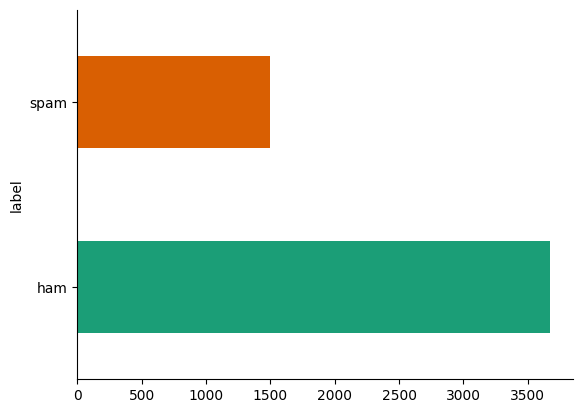

In [7]:
df.groupby('label').size()

# Check for missing values
df.isnull().sum()

df.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

# Random samples
df.sample(5)


In [8]:
spam_count = df[df['label'] == 'spam'].shape[0]
ham_count = df[df['label'] == 'ham'].shape[0]

print(f"Number of spam emails: {spam_count}")
print(f"Number of ham emails: {ham_count}")


Number of spam emails: 1499
Number of ham emails: 3672


Based on the exploration of the data, we notice that we have 1499 spam emails and 3672 ham emails in the dataset. We also can see the contents of individual emails, if we wish.

# Split Dataset to Train and Test Dataset

### Modeling Setup

We chose to use a sequential model with an embedding layer for text representation because of the simple nature of the task. Since spam email detection is  a binary classification, we think that by using this sequential model architecture it can be more effective.

Reasonable alternatives might have been more complex models like convolutional neural networks (CNNs) or recurrent neural networks (RNNs), especially if we anticipated the need to capture more intricate patterns in the text data. However, given the dataset size and the nature of the task, a simpler model was deemed sufficient.

Features include the text data converted into sequences.

Targets are binary labels (spam or ham).

Metrics include accuracy and loss.

Loss function is binary cross-entropy.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df["text"], df["label"], test_size=0.2, random_state=42)

# Split the text into words
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

# Convert text data to sequences of words
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_length = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

We use a binary cross-entropy as the loss function for binary classification. It measures the difference between the actual labels and the predicted probabilities, penalizing incorrect predictions more heavily. We chose binary cross-entropy as our loss function because it is well-suited for binary classification problems and provides a clear optimization objective for training the model.

In [10]:
model = tf.keras.Sequential([
    Embedding(input_dim=5000, output_dim=128),
    Dropout(0.5),
    tf.keras.layers.GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train the model

In [11]:
history = model.fit(X_train_pad, y_train_encoded, epochs=10,
                    validation_data=(X_test_pad, y_test_encoded),
                    verbose=2)

Epoch 1/10
130/130 - 3s - 26ms/step - accuracy: 0.7171 - loss: 0.5485 - val_accuracy: 0.7903 - val_loss: 0.3738
Epoch 2/10
130/130 - 2s - 12ms/step - accuracy: 0.9043 - loss: 0.2627 - val_accuracy: 0.9652 - val_loss: 0.1456
Epoch 3/10
130/130 - 3s - 20ms/step - accuracy: 0.9596 - loss: 0.1297 - val_accuracy: 0.9749 - val_loss: 0.0945
Epoch 4/10
130/130 - 2s - 12ms/step - accuracy: 0.9441 - loss: 0.1355 - val_accuracy: 0.9150 - val_loss: 0.2102
Epoch 5/10
130/130 - 2s - 12ms/step - accuracy: 0.9703 - loss: 0.0868 - val_accuracy: 0.9556 - val_loss: 0.0922
Epoch 6/10
130/130 - 2s - 12ms/step - accuracy: 0.9797 - loss: 0.0646 - val_accuracy: 0.9643 - val_loss: 0.0793
Epoch 7/10
130/130 - 2s - 12ms/step - accuracy: 0.9732 - loss: 0.0761 - val_accuracy: 0.9720 - val_loss: 0.0702
Epoch 8/10
130/130 - 2s - 12ms/step - accuracy: 0.9744 - loss: 0.0676 - val_accuracy: 0.9845 - val_loss: 0.0558
Epoch 9/10
130/130 - 2s - 12ms/step - accuracy: 0.9814 - loss: 0.0537 - val_accuracy: 0.9768 - val_loss:

### Validation Approach

We use these lines (below) to split the dataset into training, validation, and test sets:<br><br>
`X_train, X_val_test, y_train, y_val_test = train_test_split(df["text"], df["label"], test_size=0.3, random_state=42)`<br>
`X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)`<br><br>
First, the dataset is split into a training set and a validation-test set. The test_size is set to 0.3, which means that 30% of the dataset becomes the validation-test set and the remaining 70% becomes the training set.<br>
Then, the combined validation-test set is further split evenly (test_size=0.5) into validation and test sets. Since the validation-test set was 30% of the original dataset, each the validation and test sets contain 15% of the original data.<br>
This results in three sets: X_train, X_val, and X_test, along with their corresponding label sets (y_train, y_val, and y_test).

In [12]:
# Split the dataset
X_train, X_val_test, y_train, y_val_test = train_test_split(df["text"], df["label"], test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_length = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_val_pad = pad_sequences(X_val_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

model = tf.keras.Sequential([
    Embedding(input_dim=5000, output_dim=128),
    Dropout(0.5),
    tf.keras.layers.GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train_pad, y_train_encoded, epochs=10,
                    validation_data=(X_val_pad, y_val_encoded),
                    verbose=2)

test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_encoded)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Epoch 1/10
114/114 - 3s - 29ms/step - accuracy: 0.7013 - loss: 0.5773 - val_accuracy: 0.7320 - val_loss: 0.4479
Epoch 2/10
114/114 - 1s - 12ms/step - accuracy: 0.8406 - loss: 0.3534 - val_accuracy: 0.9420 - val_loss: 0.2135
Epoch 3/10
114/114 - 1s - 12ms/step - accuracy: 0.9475 - loss: 0.1617 - val_accuracy: 0.9755 - val_loss: 0.1086
Epoch 4/10
114/114 - 1s - 12ms/step - accuracy: 0.9602 - loss: 0.1108 - val_accuracy: 0.9755 - val_loss: 0.0955
Epoch 5/10
114/114 - 1s - 12ms/step - accuracy: 0.9627 - loss: 0.0986 - val_accuracy: 0.9008 - val_loss: 0.2714
Epoch 6/10
114/114 - 1s - 12ms/step - accuracy: 0.9765 - loss: 0.0743 - val_accuracy: 0.9794 - val_loss: 0.0738
Epoch 7/10
114/114 - 2s - 14ms/step - accuracy: 0.9787 - loss: 0.0627 - val_accuracy: 0.9665 - val_loss: 0.0803
Epoch 8/10
114/114 - 2s - 20ms/step - accuracy: 0.9735 - loss: 0.0619 - val_accuracy: 0.9858 - val_loss: 0.0595
Epoch 9/10
114/114 - 1s - 12ms/step - accuracy: 0.9831 - loss: 0.0471 - val_accuracy: 0.9652 - val_loss:

### Baseline Result

Quantitatively, after epoch 10/10 (trained on the training data with validation monitoring), our model has a loss of 0.05 and an accuracy of 0.98 on the test data. This means that we have a very low loss and 98% accuracy on the test data, which suggests excellent performance on unseen test data.

### Improvement Attempt

For adjustments, we changed Dropout to 0.5 and changed the calculation for the loss. We also tried with a bigger dataset, because our original dataset had only 10 entries, 5 spam and 5 ham. We were able to get a higher accuracy by expanding the dataset and changing these calculations.



## Predictions

In [13]:
test_sequences = tokenizer.texts_to_sequences(X_test)
test_sequences_padded = pad_sequences(test_sequences, maxlen=max_length)
test_predictions = model.predict(test_sequences_padded)

test_binary_predictions = (test_predictions > 0.5).astype(int)

for text, prediction in zip(X_test, test_binary_predictions):
    print("Text:", text)
    if prediction == 0:
        print("Prediction: Ham")
    else:
        print("Prediction: Spam")


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Text: Subject: best prices for impotence drugs
one time discount order for vl @ gra , clal 1 s !
vl @ gra discount order
today its only $ 1 . 59 per dose . new product 1 :
generic viagra , soft tabs what is soft tabs ?
only $ 1 . 62 per dose .
new product 2 :
generic clal 1 s , soft tabs what is soft clal 1 s ?
only $ 2 . 22
special offer !
vl @ gra discount order

Prediction: Spam
Text: Subject: rate for tenaska deal
daren ,
when we met regarding the rate for the tenaska gas management agreement , you
guys mentioned that it would be tied to an index - - could you restate for me
how that is to work - - it will start out 4 cents per mmbtu based on the greater
of the volumes nominated through the supply contracts or the actual
deliveries to the plant . then the fee will vary month to month ? year to year ?
based on what index ?
thanks ,
sandi
Prediction: Ham
Text: Subject: your order 8
sergio hoffmann , 25 y . o . psychotherapist , germany :
i think

In [14]:
# Prompt for predictions
new_texts = ["Hello R,\n\nI hope you are having a good start of your week. I wanted to address your concerns noted in this email. Firstly, from your wording of \"bed in hallway\", I don't think you are picturing the apartment layout or my room setup correctly. As you may know, A's apartment and my apartment have the same layout, with a smaller kitchen than usual. To compensate, the closet for the bedrooms is one large walk-in closet outside of the rooms rather than smaller personal closets within the rooms. We made the joint decision to convert this closet area into a bedroom; this is my room, hence why I am taking this accusation personally.\n\nTo counter your claim that there is no direct access to a window, this is frankly quite false. K sleeps with her bedroom door open, and since the closet space (my room) does not have its own door, K's bedroom opens directly into the edge of my space. Should there be a fire, which you seem to be claiming is the problem, I sleep 10 feet away from the window - there would be no difficulties in reaching this window.\nIn fact, my room has direct access to not only one but two windows. Again, because there is not a separate door, the space that I am referring to as my room is not an enclosed space, and has direct access to the living room area, which has the sliding glass door. Thus, sleeping where I have chosen to sleep is no different than choosing to sleep in the living room, under the code that \"all sleeping spaces must have direct access to a window\".\nWhen G, K, and I moved in, we were told that our apartment layout (with the smaller kitchen and the walk-in closet) was due to Calvin's previous housing policies, which (we were told) allowed 6 people to stay in that apartment. As I noted to A, it would not be possible for 6 people to be in the two bedrooms. My apartment mates and I were told that the area I am now using as my room was used as a bedroom previously. If this is not true, why were we told this information?\nI lived off-campus in the Project Neighborhood program for the entirety of last school year, and I experienced much greater freedoms there; returning to campus has been restrictive and frustrating. If there is one freedom I would like to be granted while living in KE, it would be to be allowed to sleep in my own apartment, in my own room, where I have been without any problems for the past month.\n\nAll good things\n\nA.M.\n\nBy the way, our entire apartment has been ridiculously hot since the AC was turned off last semester. Why don't you spend your time addressing actual problems that affect your residents instead of imposing silly and arbitrary restrictions that don't affect your residents' well-being?"]
new_texts_2 = [" Acceptance of Employment offer\n\nPersonal Assistant Service\n\nAll Email recipients of  NGO Department of Disability are encouraged to be a part of this amazing offer.  This is a part time job that will not affect your present employment or study at the campus & you'll be working from home. It’s fun, rewarding, and flexible.\n2-3 hours daily \nFour Hundred Dollar \nPart-Time Job\n\nTo apply, Be sure to visit the link below.\nApply Here  "]

new_sequences = tokenizer.texts_to_sequences(new_texts)
new_sequences_2 = tokenizer.texts_to_sequences(new_texts_2)

new_sequences_padded = pad_sequences(new_sequences, maxlen=max_length)
new_sequences_padded_2 = pad_sequences(new_sequences_2, maxlen=max_length)

new_predictions = model.predict(new_sequences_padded)
new_predictions_2 = model.predict(new_sequences_padded_2)

new_binary_predictions = (new_predictions > 0.5).astype(int)
new_binary_predictions_2 = (new_predictions_2 > 0.5).astype(int)

for text, prediction in zip(new_texts, new_binary_predictions):
    print("Text:", text)
    if prediction == 0:
        print("Prediction: Ham")
    else:
        print("Prediction: Spam")
    print("Prob: ", new_predictions)

for text, prediction in zip(new_texts_2, new_binary_predictions_2):
    print("Text:", text)
    if prediction == 0:
        print("Prediction: Ham")
    else:
        print("Prediction: Spam")
    print("Prob: ", new_predictions_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Text: Hello R,

I hope you are having a good start of your week. I wanted to address your concerns noted in this email. Firstly, from your wording of "bed in hallway", I don't think you are picturing the apartment layout or my room setup correctly. As you may know, A's apartment and my apartment have the same layout, with a smaller kitchen than usual. To compensate, the closet for the bedrooms is one large walk-in closet outside of the rooms rather than smaller personal closets within the rooms. We made the joint decision to convert this closet area into a bedroom; this is my room, hence why I am taking this accusation personally.

To counter your claim that there is no direct access to a window, this is frankly quite false. K sleeps with her bedroom door open, and since the closet space (my room) does not have its own door, K's bedroom opens directly into the edge of my space. Should there be a fire, which you

Above, we created a spam mail and fed it through the model, after it was trained. The model identified "new_texts" as spam, but it is actually an angrily-written ham email.

## Analysis

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


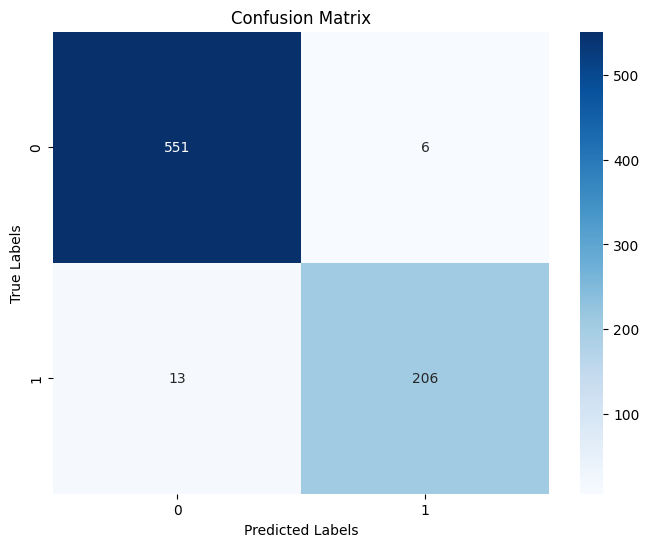

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probabilities = model.predict(X_test_pad)
y_pred = (y_pred_probabilities > 0.5).astype("int32")  # Round probabilities

# Confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

### Analysis of Errors

We have an accuracy of 98%, which means there weren't that many errors. However, according to the confusion matrix (see above), a small handful of spam and ham were misclassified. Let's see an example of a misclassified email:

In [16]:
misclassified_indices = []

for i in range(len(test_binary_predictions)):
    if test_binary_predictions[i] != y_test_encoded[i]:
        misclassified_indices.append(i)

print("Indices of Misclassified Emails:", misclassified_indices)


Indices of Misclassified Emails: [21, 84, 104, 158, 190, 238, 288, 292, 302, 333, 440, 505, 579, 600, 624, 667, 714, 734, 775]


In [17]:
misclassified_index = misclassified_indices[0]

misclassified_email_text = X_test.iloc[misclassified_index]

print("Misclassified Email Text:")
print(misclassified_email_text)
print("Predicted label: ", test_binary_predictions[misclassified_indices[0]])
print("True label:", y_test_encoded[misclassified_indices[0]])
print("Prob:", y_pred_probabilities[misclassified_indices[0]])


Misclassified Email Text:
Subject: she ' ll enjoy this .

Predicted label:  [0]
True label: 1
Prob: [0.4959414]


As you can see from the above code, we found the indices of all the misclassified emails. Then we chose one of these emails and were able to view the contents of it. In the example above, the email's true label was 0 (ham) but the predicted label was 1 (spam), so we know it was misclassified. We can analyze all the misclassified emails in this same manner and see if there are any patterns.

### Analysis of the effects of alternative choices


By adding a dropout to our model, it increases the regularization effect, leading to more robust generalization by preventing overfitting. In addition to that, the model's performance improved noticeably compared to the baseline. Both the training and validation metrics also improved. The uncertainty in estimating the model's performance with a moderate dropout rate remains relatively low.

Another thing we also tried was a different optimizer choice, Adam. With Adam,
we noticed that both the training and validation metrics may show steady improvement over epochs. It also achieves lower training loss and better generalization performance. The uncertainty in estimating the model's performance with the Adam optimizer is relatively low.


## Summary

The original question was to develop a model with a machine learning application that is capable of detecting spam emails with high accuracy. We were able to accomplish this goal, because our model had 98% accuracy at the end. This suggests that it could be used to make correct predictions as to whether email is spam or ham. We also tested the model on an input email that we came up with, and it identified it correctly.

Optimizing dropout rate contributed to this goal, as well as the size of the dataset that we used.

## Limitations and Future Directions

**Limitations:**
1. Spam email detection relies on the patterns present in the training data, thus it doesn't always account for all the diversity of real spam emails.
2. Once a spam artist knows the vulnerabilities of a model's decision boundary, they can intentionally craft spam emails to exploit the models and lead to a higher rate of false negatives.
3. The model needs to be regularly updated. This applies to our experiment, because we used an old dataset. The trends of current spam may differ from the trends of this spam dataset we found.
4. Imbalanced datasets are a risk because usually, emails are ham, and not as many are spam. This can skew the model to be biased towards the majority class (ham).
5. Complex machine learning models often lack interpretability, making it challenging to understand how the model arrives at its decisions. Lack of interpretability can hinder trust, transparency, and accountability in the decision-making process.
6. We got our dataset online, but our model could have been trained on a different, more reliable dataset, or perhaps a bigger dataset. Ideally, we would have used our own dataset, but we could not do this because none of us had enough spam mail.

**Suggestions for improvements:**
This could include collecting additional data, refining feature engineering techniques, adjusting model hyperparameters, or exploring more sophisticated modeling architectures.

**Social and ethical considerations:**
Spam email detection systems analyze the content of emails, which raises privacy concerns if the content is stored or shared with third parties. Spam email detection systems shouldn't spread the information they process, and they should only process the info that is necessary for spam detection. The systems should be transparent over what they are analyzing and how the user's email content data is being used. Also, bias in the training data may cause emails to be marked as spam or ham unnecessarily, for example if a particular word appeared in the spam training data more than other words, despite this word not actually having a strong positive correlation with spam. Wording is also different across different cultural contexts, and language barriers pose additional considerations; for example, emails in other languages than English shouldn't be flagged as spam unnecessarily. Another social implication is that spam email detection systems may inadvertently flag legitimate emails as spam (false positives) or fail to detect actual spam (false negatives), leading to inconvenience or harm to users.

## References

We got our dataset from here: https://www.kaggle.com/datasets/venky73/spam-mails-dataset/data